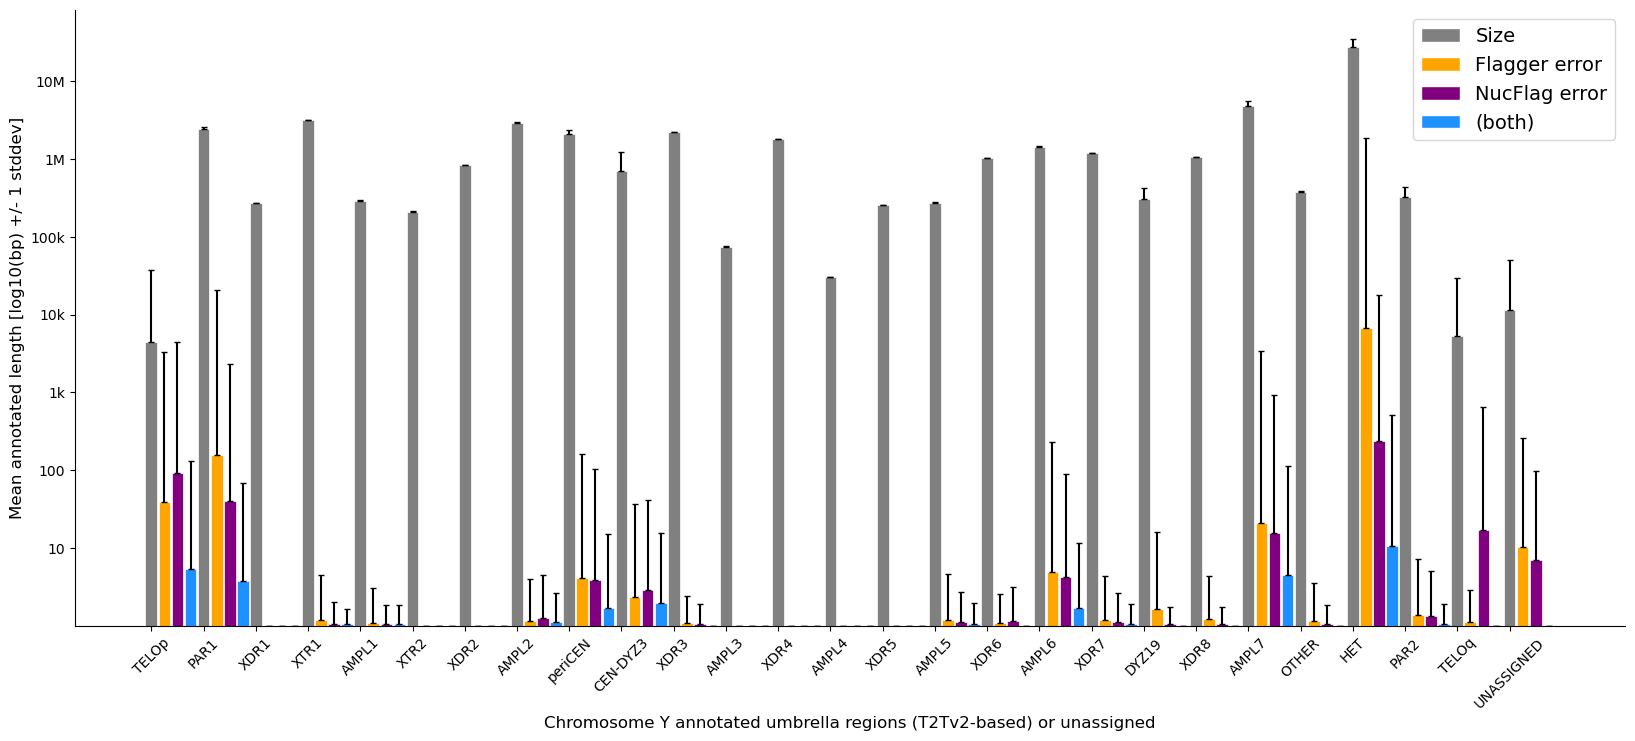

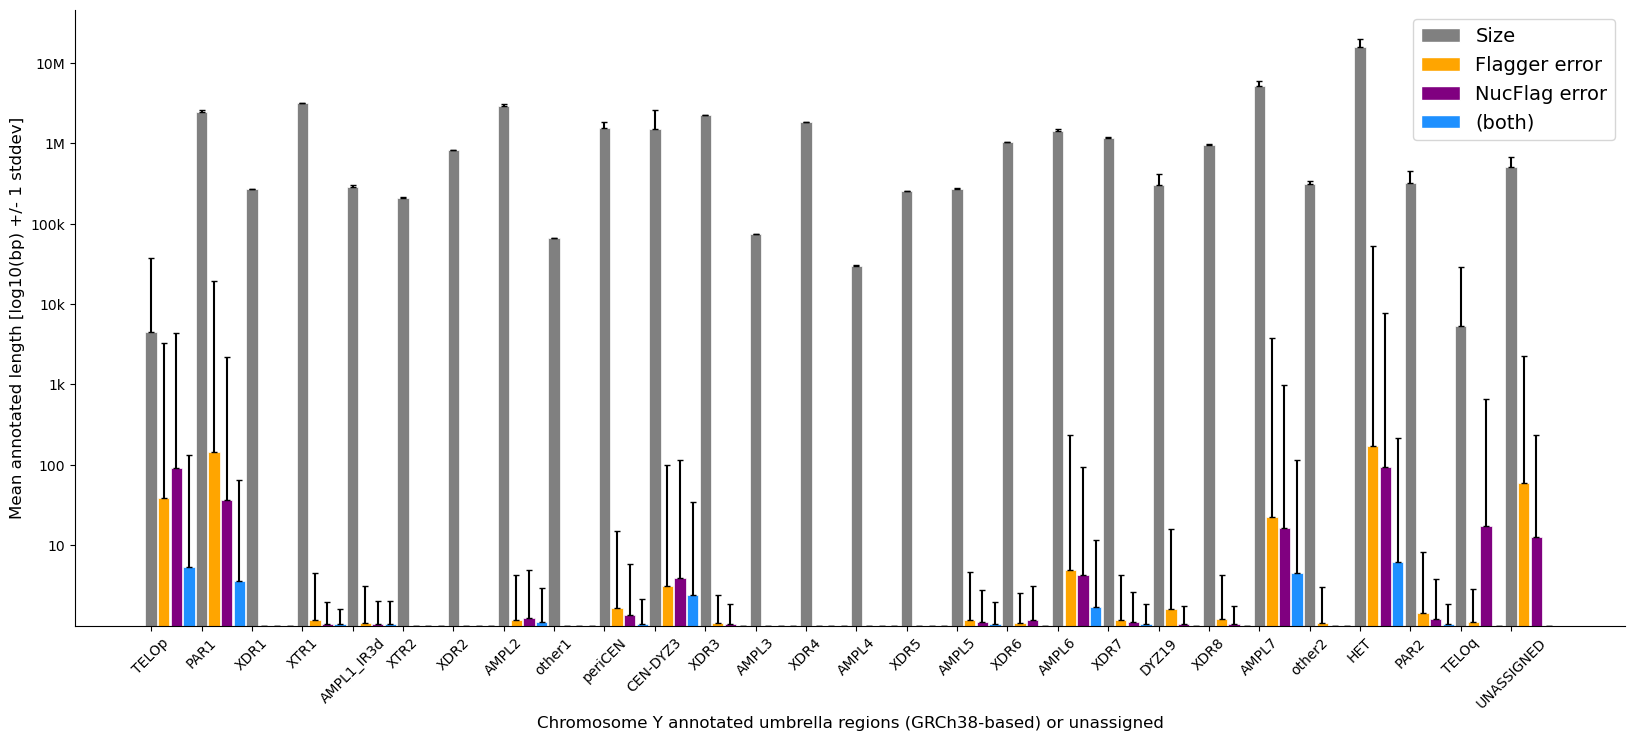

In [2]:
import pathlib as pl

# adapt relative path until it loads
cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
TABLE_ROOT = CONFIG["table_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# below: NB-specific code

PAPER_CONTENT = False
if PAPER_CONTENT:
    print("=== source")
    print(NB_REL_PATH)
    print("===")

import json

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mplpatch


def define_label_order(ref):

    umbrella_file = sorted(DATA_ROOT.joinpath(
        f"wf-data/region-labels/umbrellas/{ref}"
    ).glob(f"{ref}.*.json"))[0]
    with open(umbrella_file) as dump:
        umbrellas = json.load(dump)
    label_order = []
    for k in sorted(umbrellas.keys()):
        uni = umbrellas[k]["unified"]
        if uni in label_order:
            continue
        label_order.append(uni)
    label_order = ["TELOp"] + label_order + ["TELOq", "UNASSIGNED"]
    return label_order


summary_file_path = DATA_ROOT.joinpath("wf-data/region-labels/split_qc/struct-err_umbrella.tsv").resolve(strict=True)

summary = pd.read_csv(summary_file_path, sep="\t", header=0)
summary.set_index(["ref", "sample", "statistic"], inplace=True)
summary.fillna(0., inplace=True)

stats = ["size", "flagger_err", "nucflag_err", "both_err"]
refs = ["t2tv2", "hg38"]
ref_labels = ["T2Tv2", "GRCh38"]


def log10(series):
    adj = np.log10(series+1).round(2)
    return adj


stat_colors = {
    "size": "grey",
    "flagger_err": "orange",
    "nucflag_err": "purple",
    "both_err": "dodgerblue"
}

stat_labels = {
    "size": "Size",
    "flagger_err": "Flagger error",
    "nucflag_err": "NucFlag error",
    "both_err": "(both)"
}

stat_start_loc = {
    "size": 1,
    "flagger_err": 2,
    "nucflag_err": 3,
    "both_err": 4
}


for ref, ref_label in zip(refs, ref_labels):
    label_order = define_label_order(ref)

    plot_data = []
    colors = []
    for stat in stats:
        x_loc = stat_start_loc[stat]
        for label in label_order:
            sub = summary.xs((ref, stat), level=["ref", "statistic"])[label]
            plot_data.append((x_loc, log10(sub), stat_colors[stat]))
            x_loc += 4      

    fig, ax = plt.subplots(figsize=(20,8))
    
    bar_heights = [np.mean(values) for _, values, _ in sorted(plot_data)]
    bar_errors = [np.std(values) for _, values, _ in sorted(plot_data)]
    bar_errors = np.vstack((np.zeros_like(bar_errors), bar_errors))
    colors=[color for _, _, color in sorted(plot_data)]

    x_tick_locs = np.arange(1, len(bar_heights), step=4)
    
    boxes = ax.bar(
        np.arange(1, len(plot_data)+1),
        bar_heights,
        width=0.9,
        align="center",
        color=colors,
        edgecolor="white",
        linewidth=0.5,
        yerr=bar_errors,
        ecolor="black",
        capsize=2.
    )
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(label_order, fontsize=10, rotation=45)

    ax.set_xlabel(f"Chromosome Y annotated umbrella regions ({ref_label}-based) or unassigned", fontsize=12)
    ax.set_ylabel("Mean annotated length [log10(bp) +/- 1 stddev]", fontsize=12)
    ax.set_yticks([1, 2, 3, 4, 5, 6, 7])
    ax.set_yticklabels(["10", "100", "1k", "10k", "100k", "1M", "10M"], fontsize=10)

    legend_elements = []
    for stat in stats:
        color = stat_colors[stat]
        label = stat_labels[stat]
        elem = mplpatch.Patch(
            edgecolor="white",
            facecolor=color,
            label=label
        )
        legend_elements.append(elem)
    ax.legend(handles=legend_elements, loc='upper right', fontsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    out_file = PLOT_ROOT.joinpath("split-err-by-umbrella", f"figSX.pe_split-err-by-umbrella.{ref}.png")
    out_file.parent.mkdir(exist_ok=True, parents=True)
    plt.savefig(out_file, bbox_inches="tight", dpi=150, transparent=None, facecolor="w")
    out_file = out_file.with_suffix(".pdf")
    plt.savefig(out_file, bbox_inches="tight", transparent=None, facecolor="w")

